# JATENZO Dose Recommender - CatBoost model

**What this does, in plain terms:** given a patient (age, BMI, current testosterone, current dose) and a *target* testosterone, this model predicts the testosterone the patient would reach at **each** of the five approved doses, then recommends the dose that gets closest to the target.

This notebook uses the **CatBoost** engine. The XGBoost, LightGBM, and CatBoost notebooks are identical except for the engine, so you can compare them fairly.

Run the cells top to bottom. Each section starts with a short explanation.

## Setup

In [1]:
# --- Setup (run this first) -------------------------------------------------
import os, sys, warnings, numpy as np, pandas as pd
warnings.filterwarnings("ignore")
import matplotlib.pyplot as plt

ENGINE = "catboost"          # the model engine this notebook uses

# find the project folder and load the pipeline pieces
REPO = os.getcwd()
while not os.path.isdir(os.path.join(REPO, "src")) and REPO != os.path.dirname(REPO):
    REPO = os.path.dirname(REPO)
sys.path.insert(0, os.path.join(REPO, "src"))

from data import build_abt
from models import OutcomeTModel
from guardrails import directional_dose
from rubric import LADDER            # the five approved doses: 158/198/237/316/396

print("Ready. Using engine:", ENGINE)
print("Approved doses (mg, twice daily):", LADDER)


Ready. Using engine: catboost
Approved doses (mg, twice daily): [158, 198, 237, 316, 396]


## Step 1 - Load the data

Each row is one observation: a patient in some state was given a dose, and we recorded the testosterone they reached.

In [2]:
# Load the data. Uses your cleaned file (data/abt.csv) if present, else a built-in sample.
abt_path = os.path.join(REPO, "data", "abt.csv")
if os.path.exists(abt_path):
    df = build_abt({"source": "file", "abt_path": abt_path})
    print("Loaded cleaned data:", os.path.relpath(abt_path, REPO))
else:
    df = build_abt({"source": "synthetic"})
    print("No cleaned file found - using a built-in SAMPLE so the notebook runs.")

print(f"{len(df):,} observations from {df['subject_id'].nunique()} patients")
df.head()


Loaded cleaned data: data/abt.csv
1,200 observations from 300 patients


,subject_id,visit,age,bmi,current_T,current_dose,new_dose,outcome_T,desired_T,next_dose_rubric
0,P0000,0,56,26.6,246.6,0,396,689.0,697.5,396
1,P0000,1,56,26.6,689.0,396,198,455.3,697.5,198
2,P0000,2,56,26.6,455.3,198,396,881.9,697.5,396
3,P0000,3,56,26.6,881.9,396,158,352.9,697.5,198
4,P0001,0,63,29.8,306.3,0,396,773.5,697.5,396


## Step 2 - Train the model

We hold out a fifth of the **patients** entirely, so the model is tested on people it has never seen.

In [3]:
# Split by PATIENT (never split a patient across train/test) and train the model.
from sklearn.model_selection import GroupShuffleSplit
tr, te = next(GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=0)
              .split(df, groups=df["subject_id"]))
train, test = df.iloc[tr], df.iloc[te]

model = OutcomeTModel({"engine": ENGINE,
                       "hyperparameters": {"n_estimators": 400,
                                           "learning_rate": 0.05, "max_depth": 3}})
model.fit(train, train["outcome_T"])
print(f"Trained on {len(train)} rows; testing on {len(test)} held-out patients' rows.")


Trained on 960 rows; testing on 240 held-out patients' rows.


## Step 3 - How good is it?

Two fair tests: how accurately it predicts the final testosterone, and how often its dose recommendation matches what actually happened.

In [4]:
# TEST 1 - how well does it predict the final testosterone the patient actually reached?
pred = model.predict(test)
actual = test["outcome_T"].values
rmse = float(np.sqrt(np.mean((actual - pred) ** 2)))
r2   = float(1 - np.sum((actual - pred)**2) / np.sum((actual - actual.mean())**2))
within100 = float(np.mean(np.abs(actual - pred) <= 100))

# TEST 2 - if a patient wanted the T they actually achieved, would we recommend the
#          dose they actually took? (a fair test that needs no guesswork)
idx = {d: i for i, d in enumerate(LADDER)}
rec = model.recommend(test, actual)
taken = test["new_dose"].values
within1 = float(np.mean([abs(idx.get(a, -9) - idx.get(b, 9)) <= 1 for a, b in zip(rec, taken)]))
baseline = float(np.mean(test["current_dose"].values == taken))

print("HOW WELL IT PREDICTS FINAL TESTOSTERONE")
print(f"   Typical miss (RMSE): {rmse:,.0f} ng/dL")
print(f"   Explains {r2*100:.0f}% of the variation (R-squared)")
print(f"   Within 100 ng/dL of actual: {within100*100:.0f}% of the time")
print()
print("HOW OFTEN THE DOSE RECOMMENDATION MATCHES REALITY")
print(f"   Right dose within one step: {within1*100:.0f}% of the time")
print(f"   (naive 'keep the same dose' baseline: {baseline*100:.0f}%)")


HOW WELL IT PREDICTS FINAL TESTOSTERONE
   Typical miss (RMSE): 133 ng/dL
   Explains 65% of the variation (R-squared)
   Within 100 ng/dL of actual: 57% of the time

HOW OFTEN THE DOSE RECOMMENDATION MATCHES REALITY
   Right dose within one step: 86% of the time
   (naive 'keep the same dose' baseline: 16%)


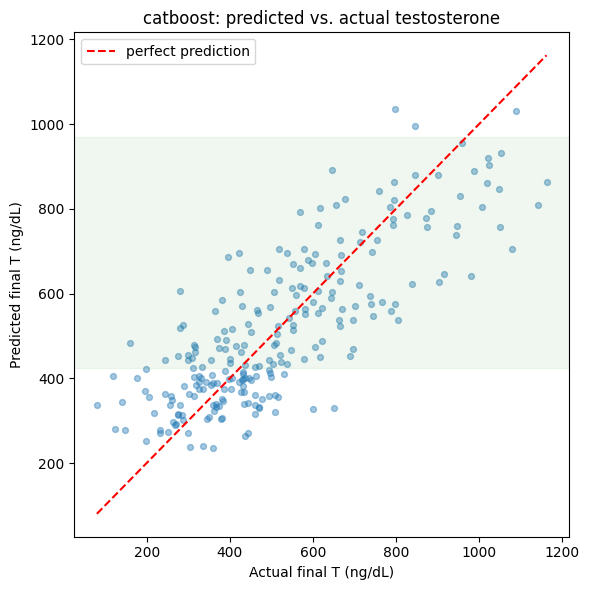

In [5]:
# Picture: predicted vs. actual final testosterone. Closer to the diagonal line = better.
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(actual, pred, alpha=0.4, s=18)
lims = [min(actual.min(), pred.min()), max(actual.max(), pred.max())]
ax.plot(lims, lims, "r--", linewidth=1.5, label="perfect prediction")
ax.axhspan(425, 970, color="green", alpha=0.06)
ax.set_xlabel("Actual final T (ng/dL)"); ax.set_ylabel("Predicted final T (ng/dL)")
ax.set_title(f"{ENGINE}: predicted vs. actual testosterone")
ax.legend(); plt.tight_layout(); plt.show()


## Step 4 - Recommend a dose for a patient

This is the actual product: try every dose, predict the outcome, pick the closest to the goal.

Patient: age 52, BMI 30.0, current T 300, on 237 mg. Goal: 650 ng/dL.


,dose_mg,predicted_final_T,distance_to_goal
0,158,231,419
1,198,283,367
2,237,322,328
3,316,481,169
4,396,590,60


--> Model's pick (closest to goal): 396 mg


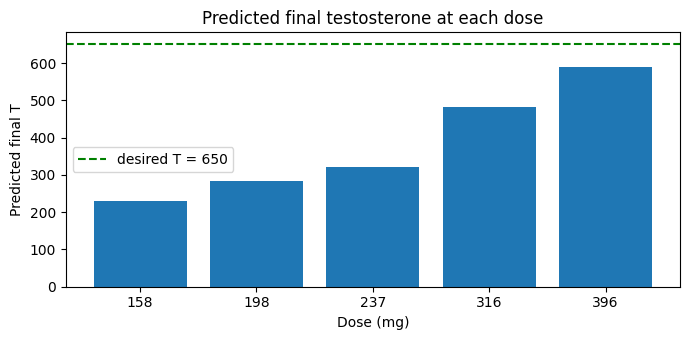

In [6]:
# Recommend a dose for one example patient.
# The model tries all five doses, predicts the resulting T for each, and picks the
# one closest to the patient's desired testosterone.
patient = {"age": 52, "bmi": 30.0, "current_T": 300, "current_dose": 237}
desired_T = 650      # where we want this patient to land (ng/dL)

table = pd.DataFrame([{"dose_mg": d,
                       "predicted_final_T":
                           round(float(model.predict(pd.DataFrame([{**patient, "new_dose": d}]))[0]))}
                      for d in LADDER])
table["distance_to_goal"] = (table["predicted_final_T"] - desired_T).abs()
best = int(table.sort_values("distance_to_goal").iloc[0]["dose_mg"])

print(f"Patient: age {patient['age']}, BMI {patient['bmi']}, "
      f"current T {patient['current_T']}, on {patient['current_dose']} mg. Goal: {desired_T} ng/dL.")
display(table)
print(f"--> Model's pick (closest to goal): {best} mg")

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.bar(table["dose_mg"].astype(str), table["predicted_final_T"])
ax.axhline(desired_T, color="green", linestyle="--", label=f"desired T = {desired_T}")
ax.set_xlabel("Dose (mg)"); ax.set_ylabel("Predicted final T"); ax.legend()
ax.set_title("Predicted final testosterone at each dose"); plt.tight_layout(); plt.show()


## Step 5 - Guardrails

The guardrails are a plain-English safety net applied **after** the model, so the recommendation always moves in the sensible direction:

1. **New patient** -> start at the standard 237 mg.
2. **Keep T the same** -> keep the current dose.
3. **Want higher T** -> the dose must go up.
4. **Want lower T** -> the dose must go down.

They never invent a dose - they only correct the direction of the model's suggestion.

In [7]:
# Guardrails: a simple safety layer that makes the recommendation's DIRECTION sensible.
# It runs AFTER the model and only corrects the direction - it never invents a dose.
def show(label, proposed, cur_dose, cur_T, want_T):
    d = directional_dose(proposed, cur_dose, cur_T, want_T)
    print(f"{label:38s} -> {d.dose:>3} mg   ({d.rationale})")

print("THE FOUR GUARDRAILS\n")
show("1. New patient (no dose yet)",        316, 0,   300, 600)
show("2. Want to KEEP T the same",          316, 237, 600, 610)
show("3. Want HIGHER T (force step up)",    158, 237, 400, 900)
show("4. Want LOWER T (force step down)",   396, 316, 900, 400)


THE FOUR GUARDRAILS

1. New patient (no dose yet)           -> 237 mg   (Treatment-naive: standard start dose.)
2. Want to KEEP T the same             -> 237 mg   (Goal is to maintain T: keep current dose.)
3. Want HIGHER T (force step up)       -> 316 mg   (Goal is higher T: dose stepped up.)
4. Want LOWER T (force step down)      -> 237 mg   (Goal is lower T: dose stepped down.)


## Summary

The **CatBoost** model predicts final testosterone at each dose and recommends the one closest to the target, with guardrails keeping the direction sensible. Swap this notebook for the XGBoost / LightGBM / CatBoost version to compare engines on the same data.

*Numbers here use a built-in sample until the real cleaned data (`data/abt.csv`) is added - then re-run and the numbers update.*